<a href="https://colab.research.google.com/github/helenakkr/PCD_Assignment01/blob/main/PCD_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PCD Assignment 01**
##**Down Sampling dan Up Sampling Pada Citra Digital**

Analisis pengaruh beberapa metode **down sampling** dan **up sampling** terhadap citra digital.

Metode yang digunakan meliputi:

**Down Sampling**
- Maximum
- Average
- Median

**Up Sampling**
- Nearest Neighbor
- Bilinear
- Bicubic

Beberapa citra dengan karakteristik yang berbeda sengaja digunakan agar pengaruh masing-masing metode dapat diamati dengan lebih detail dan jelas.

## 1. Import Library

Percobaan ini menggunakan beberapa library Python, yaitu:

- **NumPy** untuk melakukan operasi numerik pada data citra.
- **Matplotlib** untuk menampilkan dan membandingkan citra.
- **Scikit-image** untuk menyediakan citra sampel serta membantu proses reduksi blok piksel.
- **OpenCV** untuk melakukan perubahan ukuran citra pada proses up sampling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from skimage import data
from skimage.measure import block_reduce

## 2. Citra yang Digunakan

Percobaan ini menggunakan beberapa citra dengan karakteristik yang berbeda.

- **Camera** merupakan citra grayscale alami yang memiliki variasi tekstur, tepi objek, dan perubahan intensitas.
- **Checkerboard** citra ini memiliki pola hitam-putih yang berulang dan perubahan intensitas yang tajam cocok untuk menunjukkan kehilangan detail pada down sampling.
- **Text** memiliki banyak garis tipis dan tepi yang tajam sehingga cocok untuk membandingkan metode interpolasi pada up sampling.
- **Astronaut** merupakan citra RGB alami yang memiliki warna, tekstur, serta detail objek sehingga dapat digunakan untuk melihat pengaruh interpolasi pada citra nyata.

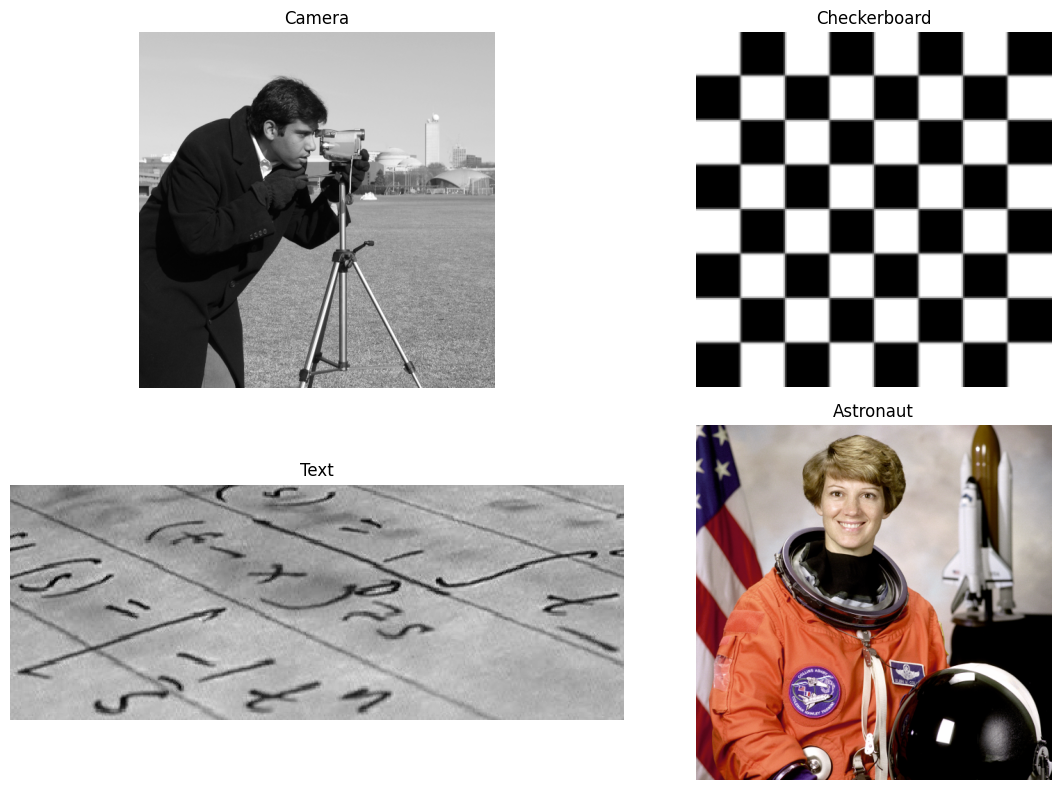

In [2]:
camera = data.camera()
checkerboard = data.checkerboard()
text = data.text()
astronaut = data.astronaut()

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(camera, cmap="gray")
plt.title("Camera")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(checkerboard, cmap="gray")
plt.title("Checkerboard")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(text, cmap="gray")
plt.title("Text")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(astronaut)
plt.title("Astronaut")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Down Sampling

Down sampling merupakan proses untuk mengurangi resolusi spasial suatu citra. Pada proses ini, beberapa piksel yang berdekatan akan direpresentasikan menjadi jumlah piksel yang lebih sedikit.

Pada percobaan ini digunakan blok berukuran **4 × 4 piksel**. Setiap blok tersebut akan diubah menjadi satu piksel menggunakan tiga metode berikut:

- **Maximum**, yaitu mengambil nilai intensitas terbesar dari setiap blok.
- **Average**, yaitu mengambil nilai rata-rata intensitas dari setiap blok.
- **Median**, yaitu mengambil nilai tengah dari intensitas piksel pada setiap blok.

Percobaan ini juga menggunakan faktor reduksi sebesar 4 supaya perbedaan hasil dari masing-masing metode dapat terlihat dengan lebih jelas.

In [3]:
def downsample_max(image, factor=4):
    if image.ndim == 3:
        return block_reduce(
            image,
            block_size=(factor, factor, 1),
            func=np.max
        )
    else:
        return block_reduce(
            image,
            block_size=(factor, factor),
            func=np.max
        )


def downsample_average(image, factor=4):
    if image.ndim == 3:
        return block_reduce(
            image,
            block_size=(factor, factor, 1),
            func=np.mean
        )
    else:
        return block_reduce(
            image,
            block_size=(factor, factor),
            func=np.mean
        )


def downsample_median(image, factor=4):
    if image.ndim == 3:
        return block_reduce(
            image,
            block_size=(factor, factor, 1),
            func=np.median
        )
    else:
        return block_reduce(
            image,
            block_size=(factor, factor),
            func=np.median
        )

### 3.1 Percobaan pada Citra Grayscale Alami

Citra `camera` digunakan untuk mengamati pengaruh metode Maximum, Average, dan Median terhadap detail objek, tekstur, tepi, serta perubahan intensitas pada citra alami.

Original size : (512, 512)
Downsampled size : (128, 128)


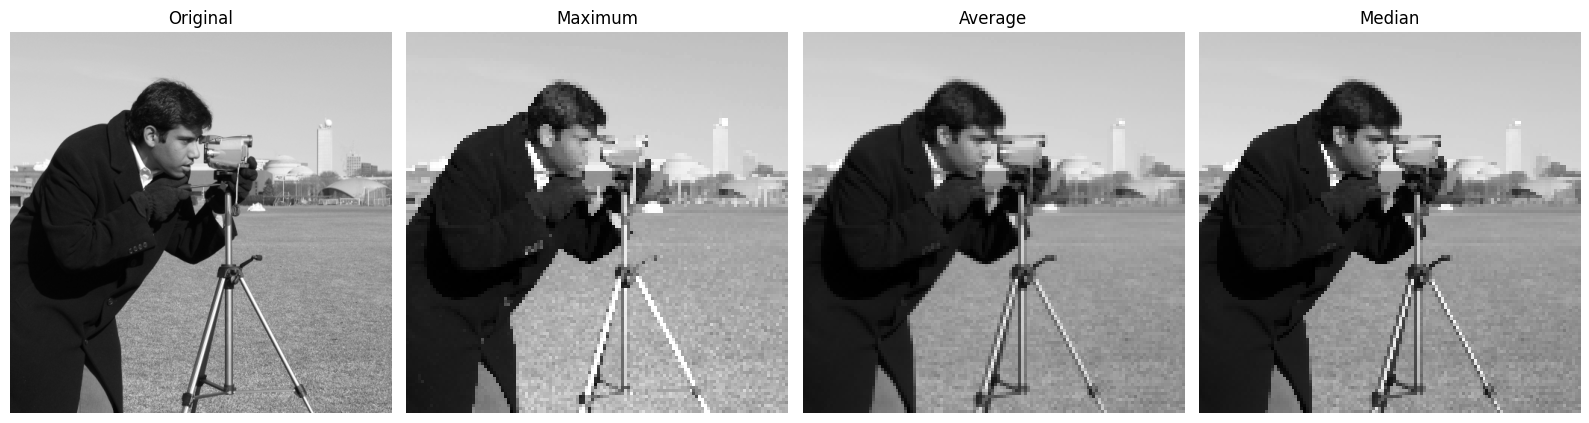

In [4]:
camera_max = downsample_max(camera)
camera_avg = downsample_average(camera)
camera_med = downsample_median(camera)

print("Original size :", camera.shape)
print("Downsampled size :", camera_avg.shape)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(camera, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(camera_max, cmap="gray", interpolation="nearest")
plt.title("Maximum")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(camera_avg, cmap="gray", interpolation="nearest")
plt.title("Average")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(camera_med, cmap="gray", interpolation="nearest")
plt.title("Median")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Analisis Hasil

Pada metode **Maximum**, setiap blok direpresentasikan oleh piksel dengan intensitas tertinggi. Hal ini menyebabkan bagian citra yang terang cenderung lebih dominan.

Metode **Average** menghasilkan perubahan intensitas yang lebih halus karena nilai piksel baru diperoleh dari rata-rata seluruh piksel dalam setiap blok. Namun, metode ini juga menyebabkan beberapa detail dan tepi objek menjadi lebih halus.

Sementara itu, metode **Median** menggunakan nilai tengah dari setiap blok sehingga tidak terlalu dipengaruhi oleh nilai piksel yang sangat tinggi maupun sangat rendah.

Ketiga metode menyebabkan berkurangnya detail citra karena ukuran citra telah diperkecil dari resolusi awal.

### 3.2 Percobaan pada Citra dengan Pola Berulang

Citra `checkerboard` memiliki pola hitam-putih yang berulang dengan perubahan intensitas yang sangat tajam. Karakteristik tersebut membuat citra ini cocok digunakan untuk mengamati kehilangan informasi spasial akibat proses down sampling.

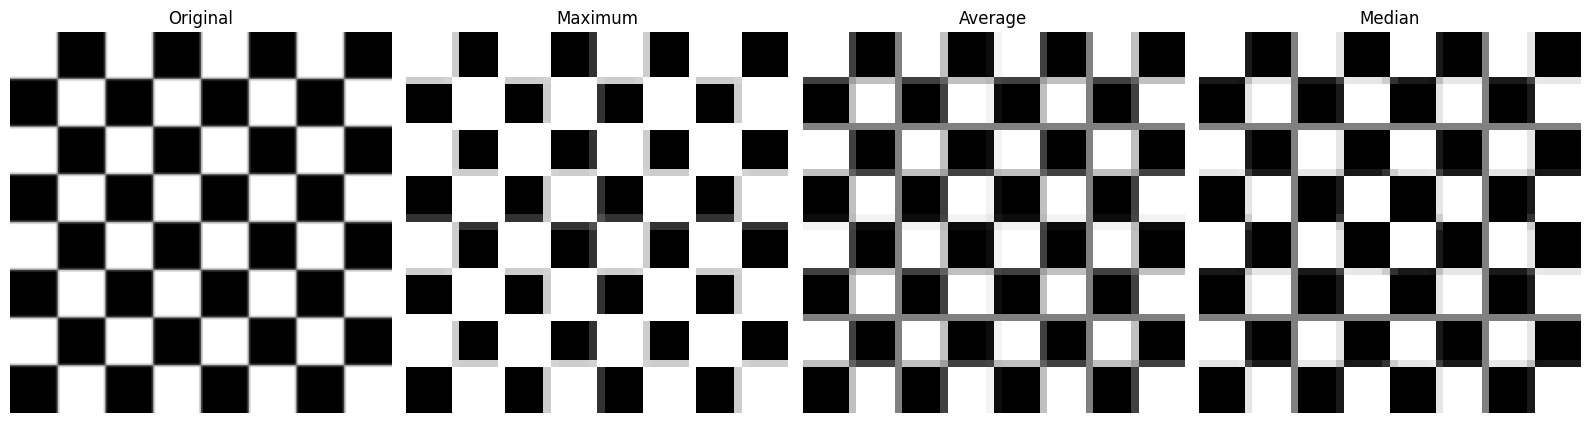

In [5]:
checker_max = downsample_max(checkerboard)
checker_avg = downsample_average(checkerboard)
checker_med = downsample_median(checkerboard)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(checkerboard, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(checker_max, cmap="gray", interpolation="nearest")
plt.title("Maximum")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(checker_avg, cmap="gray", interpolation="nearest")
plt.title("Average")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(checker_med, cmap="gray", interpolation="nearest")
plt.title("Median")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Analisis Hasil

Pengaruh down sampling terlihat lebih jelas pada citra checkerboard dibandingkan citra alami karena citra ini memiliki banyak perubahan intensitas yang tajam.

Metode **Maximum** cenderung mempertahankan piksel dengan intensitas tinggi sehingga bagian putih menjadi lebih dominan. Metode **Average** menghasilkan nilai abu-abu pada beberapa bagian karena piksel hitam dan putih dirata-ratakan. Sementara itu, metode **Median** mempertahankan nilai intensitas yang paling mewakili piksel dalam suatu blok.

Percobaan ini menunjukkan bahwa citra dengan pola berfrekuensi tinggi lebih sensitif terhadap pengurangan resolusi spasial.

## 4. Up Sampling

Up sampling merupakan proses untuk meningkatkan ukuran atau resolusi spasial suatu citra dengan memperkirakan nilai piksel baru.

Pada percobaan ini digunakan tiga metode interpolasi:

- **Nearest Neighbor**: menentukan nilai piksel baru berdasarkan piksel terdekat.
- **Bilinear**: memperkirakan nilai piksel baru menggunakan beberapa piksel di sekitarnya.
- **Bicubic**: menggunakan lingkungan piksel yang lebih luas untuk menghasilkan perubahan intensitas yang lebih halus.

Agar perbedaan ketiga metode dapat diamati dengan jelas, citra terlebih dahulu diperkecil menjadi seperempat ukuran aslinya, kemudian diperbesar kembali hingga mencapai ukuran awal.

### 4.1 Percobaan pada Citra Teks

Citra `text` memiliki banyak garis tipis serta tepi yang tajam. Karakteristik tersebut membuat perubahan akibat proses interpolasi lebih mudah diamati, terutama pada bagian tepi huruf.

Original size : (172, 448)
Low-resolution size : (43, 112)
Upsampled size : (172, 448)


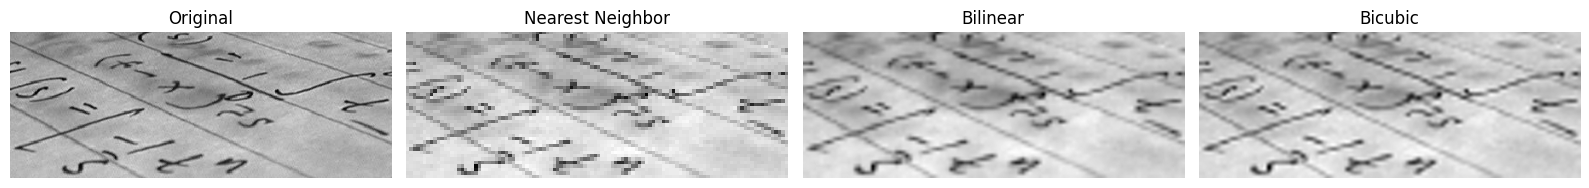

In [6]:
h, w = text.shape

small_text = cv2.resize(
    text,
    (w // 4, h // 4),
    interpolation=cv2.INTER_AREA
)

text_nn = cv2.resize(
    small_text,
    (w, h),
    interpolation=cv2.INTER_NEAREST
)

text_bilinear = cv2.resize(
    small_text,
    (w, h),
    interpolation=cv2.INTER_LINEAR
)

text_bicubic = cv2.resize(
    small_text,
    (w, h),
    interpolation=cv2.INTER_CUBIC
)

print("Original size :", text.shape)
print("Low-resolution size :", small_text.shape)
print("Upsampled size :", text_nn.shape)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(text, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(text_nn, cmap="gray", interpolation="nearest")
plt.title("Nearest Neighbor")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(text_bilinear, cmap="gray")
plt.title("Bilinear")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(text_bicubic, cmap="gray")
plt.title("Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Analisis Hasil

Metode **Nearest Neighbor** menghasilkan efek piksel yang paling jelas. Hal ini terjadi karena setiap piksel baru hanya mengambil nilai dari piksel terdekat tanpa melakukan perhitungan terhadap piksel lain.

Metode **Bilinear** menghasilkan tepi yang lebih halus, tetapi beberapa bagian teks terlihat lebih kabur karena nilai piksel baru dihitung berdasarkan piksel-piksel di sekitarnya.

Metode **Bicubic** menghasilkan perubahan intensitas yang lebih halus sekaligus mampu mempertahankan bentuk tepi dengan lebih baik dibandingkan Bilinear.

Meskipun ukuran citra kembali sama dengan citra asli, detail yang telah hilang pada saat citra diperkecil tidak dapat dikembalikan sepenuhnya.

### 4.2 Percobaan pada Citra RGB Alami

Citra `astronaut` digunakan untuk mengamati pengaruh metode interpolasi terhadap citra alami yang memiliki warna, tekstur, tepi objek, dan detail wajah.

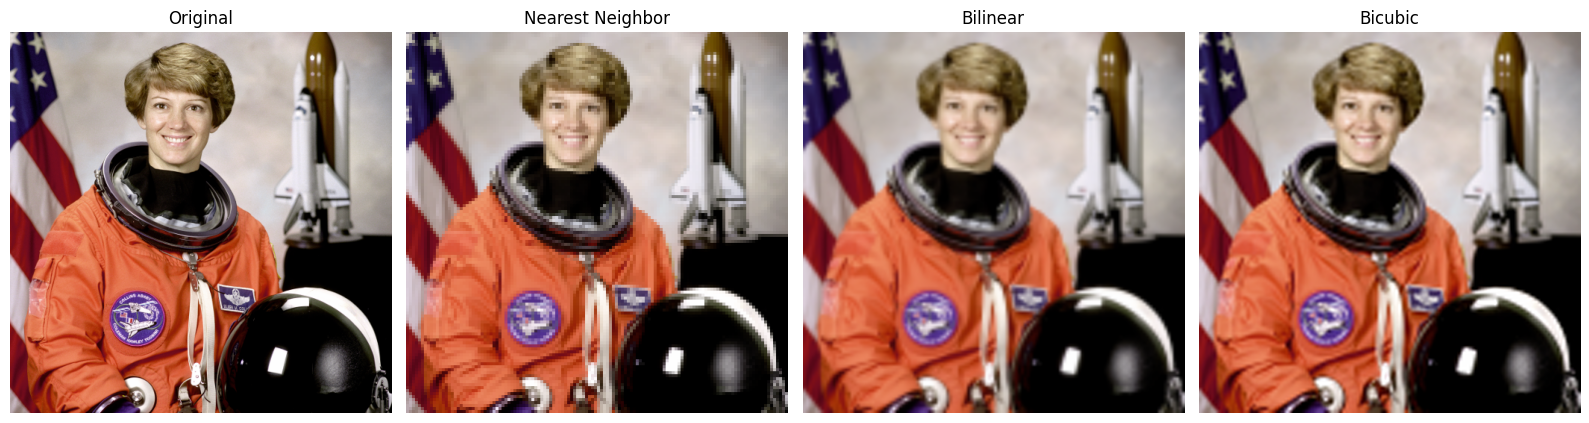

In [7]:
h, w = astronaut.shape[:2]

small_astronaut = cv2.resize(
    astronaut,
    (w // 4, h // 4),
    interpolation=cv2.INTER_AREA
)

astro_nn = cv2.resize(
    small_astronaut,
    (w, h),
    interpolation=cv2.INTER_NEAREST
)

astro_bilinear = cv2.resize(
    small_astronaut,
    (w, h),
    interpolation=cv2.INTER_LINEAR
)

astro_bicubic = cv2.resize(
    small_astronaut,
    (w, h),
    interpolation=cv2.INTER_CUBIC
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(astronaut)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(astro_nn)
plt.title("Nearest Neighbor")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(astro_bilinear)
plt.title("Bilinear")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(astro_bicubic)
plt.title("Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

Pada tampilan citra secara keseluruhan, perbedaan antara ketiga metode interpolasi tidak selalu mudah diamati. Agar terlihat lebih jelas dilakukan pengamatan lebih dekat pada salah satu bagian citra agar perbedaan pada tekstur dan tepi objek dapat terlihat lebih jelas.

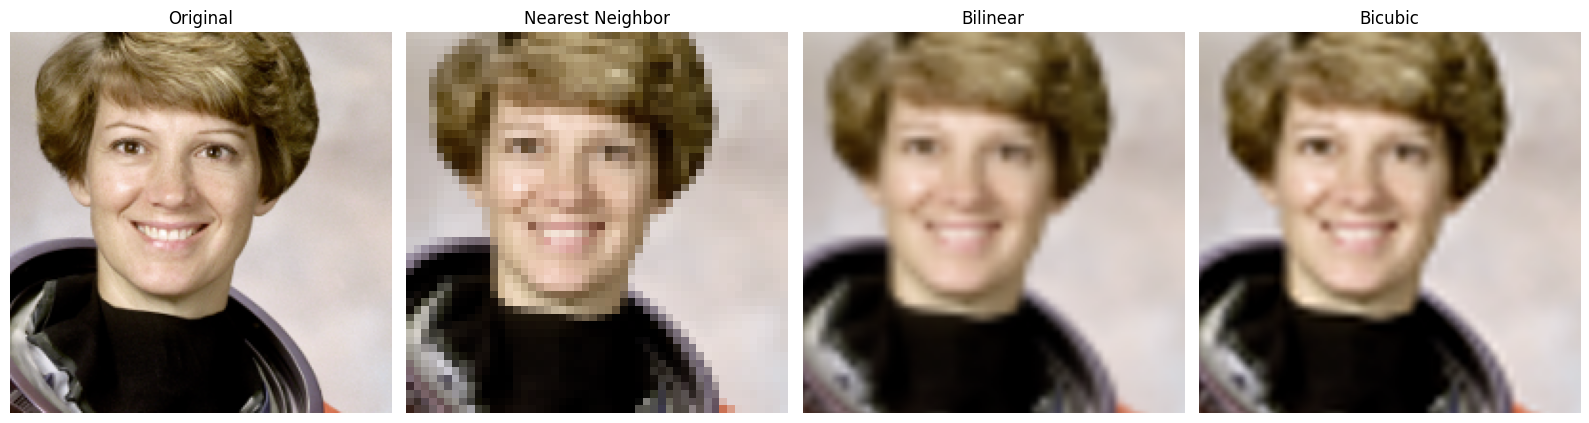

In [8]:
y1, y2 = 40, 240
x1, x2 = 140, 340

crop_original = astronaut[y1:y2, x1:x2]
crop_nn = astro_nn[y1:y2, x1:x2]
crop_bilinear = astro_bilinear[y1:y2, x1:x2]
crop_bicubic = astro_bicubic[y1:y2, x1:x2]

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(crop_original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(crop_nn, interpolation="nearest")
plt.title("Nearest Neighbor")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(crop_bilinear)
plt.title("Bilinear")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(crop_bicubic)
plt.title("Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Analisis Hasil

Setelah bagian tertentu dari citra diperbesar, perbedaan metode interpolasi terlihat lebih jelas.

Pada **Nearest Neighbor**, bentuk piksel terlihat lebih kotak terutama pada bagian tepi dan detail wajah. **Bilinear** mampu mengurangi efek tersebut, tetapi menghasilkan citra yang lebih halus dan sedikit blur.

Sementara itu, **Bicubic** memberikan hasil yang lebih halus dengan detail tepi yang relatif lebih terjaga dibandingkan Bilinear.

Hasil ini juga menunjukkan bahwa peningkatan resolusi citra melalui up sampling tidak sama dengan mengembalikan detail citra asli. Metode interpolasi hanya memperkirakan nilai piksel baru berdasarkan informasi yang masih tersedia pada citra beresolusi rendah.

## 5. Analisis Keseluruhan

Berdasarkan percobaan yang telah dilakukan, proses down sampling dan up sampling memberikan pengaruh yang berbeda terhadap resolusi serta kualitas visual suatu citra.

Pada proses **down sampling**, beberapa piksel yang berdekatan harus direpresentasikan oleh jumlah piksel yang lebih sedikit. Kondisi tersebut menyebabkan berkurangnya informasi spasial pada citra. Metode Maximum, Average, dan Median menghasilkan karakteristik yang berbeda karena menggunakan cara yang berbeda untuk menentukan nilai piksel baru.

Metode Maximum mengambil nilai intensitas terbesar sehingga bagian terang pada citra cenderung lebih dominan. Metode Average menghasilkan perubahan intensitas yang lebih halus karena menggunakan nilai rata-rata dalam setiap blok, tetapi dapat menyebabkan detail dan tepi menjadi lebih halus. Metode Median menggunakan nilai tengah sehingga lebih tahan terhadap nilai intensitas yang ekstrem.

Pengaruh down sampling juga bergantung pada karakteristik citra. Pada citra alami seperti `camera`, pengurangan resolusi terutama terlihat pada hilangnya tekstur halus dan detail pada tepi objek. Pada citra `checkerboard`, perubahan terlihat lebih jelas karena citra tersebut memiliki pola berulang serta perubahan intensitas yang sangat tajam. Hal ini menunjukkan bahwa citra dengan informasi spasial berfrekuensi tinggi lebih sensitif terhadap proses down sampling.

Pada proses **up sampling**, ukuran citra diperbesar dengan cara memperkirakan nilai piksel baru. Metode Nearest Neighbor menghasilkan proses yang sederhana, tetapi menimbulkan efek kotak atau pixelation karena piksel baru hanya mengambil nilai dari piksel terdekat. Bilinear menghasilkan citra yang lebih halus karena menggunakan beberapa piksel di sekitar posisi baru, tetapi dapat menimbulkan efek blur. Bicubic menggunakan lingkungan piksel yang lebih luas sehingga secara visual dapat menghasilkan transisi yang lebih halus dan mempertahankan detail tepi dengan lebih baik.

Perbedaan metode interpolasi terlihat sangat jelas pada citra `text` karena citra tersebut memiliki banyak garis dan tepi tajam. Pada citra alami seperti `astronaut`, perbedaannya lebih sulit diamati ketika citra dilihat secara keseluruhan. Namun, setelah dilakukan pengamatan pada bagian citra yang diperbesar, efek pixelation dan blur dapat terlihat dengan lebih jelas.

Secara keseluruhan, tidak terdapat satu metode sampling yang selalu paling baik untuk seluruh jenis citra. Pemilihan metode bergantung pada karakteristik citra serta kebutuhan pengolahan, misalnya mempertahankan tepi, menghasilkan transisi yang halus, atau mengurangi kompleksitas komputasi.

## 6. Kesimpulan

Down sampling menyebabkan berkurangnya resolusi spasial dan hilangnya sebagian informasi pada citra. Metode Maximum, Average, dan Median menghasilkan karakteristik yang berbeda karena menggunakan pendekatan yang berbeda dalam menentukan nilai piksel hasil.

Sementara itu, up sampling dapat meningkatkan ukuran citra, tetapi tidak dapat mengembalikan seluruh informasi yang telah hilang. Nearest Neighbor menghasilkan citra yang lebih pixelated, Bilinear menghasilkan citra yang lebih halus tetapi cenderung blur, sedangkan Bicubic umumnya memberikan keseimbangan yang lebih baik antara kehalusan citra dan pemeliharaan detail tepi.

Percobaan juga menunjukkan bahwa pengaruh suatu metode sampling sangat bergantung pada karakteristik citra yang digunakan.